## Step 1: Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter

print("All imports successful")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

All imports successful
pandas: 2.3.3
numpy: 2.2.6


## Step 2: Load the Raw Clinical Data

The TCGA-LUAD clinical file (`LUAD.merged_only_clinical_clin_format.txt`) is a tab-separated file in **transposed format**:
- Each **row** is a clinical variable (e.g. age, survival time, stage)
- Each **column** is a patient

We use the `merged_only_clinical` file — it contains only core patient-level clinical variables (527 total), without biospecimen and admin noise.

Missing values are encoded as `NA`, `[Not Available]`, or `[Unknown]` — we tell pandas to treat all of these as proper missing values on load.

**File:** `gdac.broadinstitute.org_LUAD.Merge_Clinical.Level_1.2016012800.0.0/LUAD.merged_only_clinical_clin_format.txt`  
**Source:** GDAC Broad Institute (TCGA LUAD Level 1 Clinical Data)  
**Expected shape before transpose:** 527 variables × 522 patients

In [2]:
CLINICAL_PATH = (
    "data/raw/gdac.broadinstitute.org_LUAD.Merge_Clinical.Level_1"
    ".2016012800.0.0/LUAD.merged_only_clinical_clin_format.txt"
)

# Load raw file
# rows = clinical variables, columns = patients
raw = pd.read_csv(
    CLINICAL_PATH,
    sep='\t',
    index_col=0,
    header=0,
    low_memory=False,
    na_values=['NA', '[Not Available]', '[Unknown]']
)

print(f"Raw shape: {raw.shape}  (variables × patients)")

# Transpose so rows = patients, columns = variables
clinical = raw.T
print(f"Transposed shape: {clinical.shape}  (patients × variables)")

# Set proper TCGA patient barcode as the row index
clinical = clinical.set_index('patient.bcr_patient_barcode')
print(f"\nIndex name: {clinical.index.name}")
print(f"First 5 patient IDs: {clinical.index[:5].tolist()}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/gdac.broadinstitute.org_LUAD.Merge_Clinical.Level_1.2016012800.0.0/LUAD.merged_only_clinical_clin_format.txt'

## Step 3: Extract Survival-Relevant Columns

From 527 clinical variables we extract only the 6 columns needed for survival analysis:

| Column | Role |
|---|---|
| `vital_status` | Did the patient die during the study? (dead/alive) |
| `days_to_death` | Days from diagnosis to death — only present if dead |
| `days_to_last_followup` | Days from diagnosis to last contact — present if alive/censored |
| `age` | Age at diagnosis |
| `gender` | Biological sex |
| `stage` | Pathologic cancer stage (I, II, III, IV) |

In [ ]:
cols = [
    'patient.vital_status',
    'patient.days_to_death',
    'patient.days_to_last_followup',
    'patient.age_at_initial_pathologic_diagnosis',
    'patient.gender',
    'patient.stage_event.pathologic_stage'
]

surv = clinical[cols].copy()

# Rename to shorter, cleaner names
surv.columns = [
    'vital_status',
    'days_to_death',
    'days_to_last_followup',
    'age',
    'gender',
    'stage'
]

print(f"Shape: {surv.shape}")
surv.head(10)

Shape: (522, 6)


,vital_status,days_to_death,days_to_last_followup,age,gender,stage
patient.bcr_patient_barcode,,,,,,
tcga-05-4244,alive,NaN,0,70,male,stage iv
tcga-05-4245,alive,NaN,395,81,male,stage iiia
tcga-05-4249,alive,NaN,1158,67,male,stage ib
tcga-05-4250,dead,121,NaN,79,female,stage iiia
tcga-05-4382,alive,NaN,607,68,male,stage ib
tcga-05-4384,alive,NaN,426,66,male,stage iiia
tcga-05-4389,alive,NaN,1369,70,male,stage ia
tcga-05-4390,alive,NaN,1126,58,female,stage ib
tcga-05-4395,dead,0,NaN,76,male,stage iiib


## Step 4: Understand and Clean the Survival Columns

**Key concept — censoring:**  
- `vital_status = dead` → patient died during study → use `days_to_death` as survival time  
- `vital_status = alive` → patient still alive at last contact → use `days_to_last_followup` as survival time  

We combine both into a single `survival_time` column, then clean missing values and convert data types.


* surv['survival_time'] = surv['days_to_death'].fillna(surv['days_to_last_followup'])
    For each patient, we want one number — how long did we observe them? But that number lives in two different columns depending on whether they died or not. So we say: take days_to_death as the primary source. Wherever that's NaN (meaning the patient didn't die), fill it in with days_to_last_followup instead.
    Result: every patient now has a single survival_time number.

* surv['event'] = (surv['vital_status'].str.lower() == 'dead').astype(int)
    Survival models don't understand the word "dead" — they need a number. So we create a binary column: 1 if the patient died, 0 if they're alive or censored.
    Breaking it down step by step: surv['vital_status'].str.lower() converts everything to lowercase so "Dead", "DEAD", "dead" all match. == 'dead' produces True/False for each patient. .astype(int) converts True → 1 and False → 0.



In [ ]:
# convert numeric column - they loaded as strings (object type)

surv['days_to_death'] = pd.to_numeric(surv['days_to_death'], errors = 'coerce' )
surv['days_to_last_followup'] = pd.to_numeric(surv['days_to_last_followup'], errors = 'coerce' ) # If a value cannot be converted to a number, replace it with NaN instead of raising an error.
surv['age'] = pd.to_numeric(surv['age'], errors='coerce')

# Build survival_time:
# If dead -> use days_to_death
# If alive -> use days_last_followup

surv['survival_time'] = surv['days_to_death'].fillna(surv['days_to_last_followup'])

# Build event flag:
# 1 = died (event occurred), 0 = alive/censored (event did not occur)
surv['event'] = (surv['vital_status'].str.lower() == 'dead').astype(int)

print("Survival time stats:")
print(surv['survival_time'].describe())
print(f"\nEvent distribution (0=alive, 1=dead):")
print(surv['event'].value_counts())
print(f"\nMissing survival_time: {surv['survival_time'].isna().sum()}")




Survival time stats:
count     503.000000
mean      542.779324
std       831.862896
min         0.000000
25%        47.000000
50%       231.000000
75%       745.500000
max      6812.000000
Name: survival_time, dtype: float64

Event distribution (0=alive, 1=dead):
event
0    395
1    127
Name: count, dtype: int64

Missing survival_time: 19


* count     503.000000   ← 503 patients have a valid survival time (522 - 19 missing)
* mean      542.779324   ← average survival ~543 days (~1.5 years)
* min         0.000000   ← at least one patient with 0 days — suspicious, we'll investigate
* 25%        47.000000   ← 25% of patients survived less than 47 days* 
* 50%       231.000000   ← median survival is 231 days (~7.5 months)
* 75%       745.500000   ← 75% survived less than ~2 years
* max      6812.000000   ← longest followed patient: ~18.7 years

## Step 5: Drop Missing and Invalid Survival Times

We drop patients where survival time is missing (19 patients) or zero days — 
zero is biologically implausible and likely a data entry error.

After dropping, we confirm the final clean dataset size.

In [ ]:
# Drop patients with missing survival time 

surv = surv.dropna(subset=['survival_time'])
print(f"After dropping missing survival_time: {surv.shape[0]} patients")

# Drop patients with survival time of 0 — biologically implausible
surv = surv[surv['survival_time'] > 0]
print(f"After dropping zero survival_time: {surv.shape[0]} patients")


# Quick sanity check — no negatives crept in
assert surv['survival_time'].min() > 0, "Negative survival times found!"
print(f"\nSurvival time range: {surv['survival_time'].min():.0f} to {surv['survival_time'].max():.0f} days")
print(f"Event rate: {surv['event'].mean():.1%} of patients died")


After dropping missing survival_time: 503 patients
After dropping zero survival_time: 484 patients

Survival time range: 1 to 6812 days
Event rate: 25.2% of patients died


## Step 6: Exploratory Data Analysis (EDA)

Before building any model, we visually inspect the data.  
Key questions:
- What does the survival time distribution look like?
- How are patients split by gender and stage?
- How much missing data do we have in our feature columns?

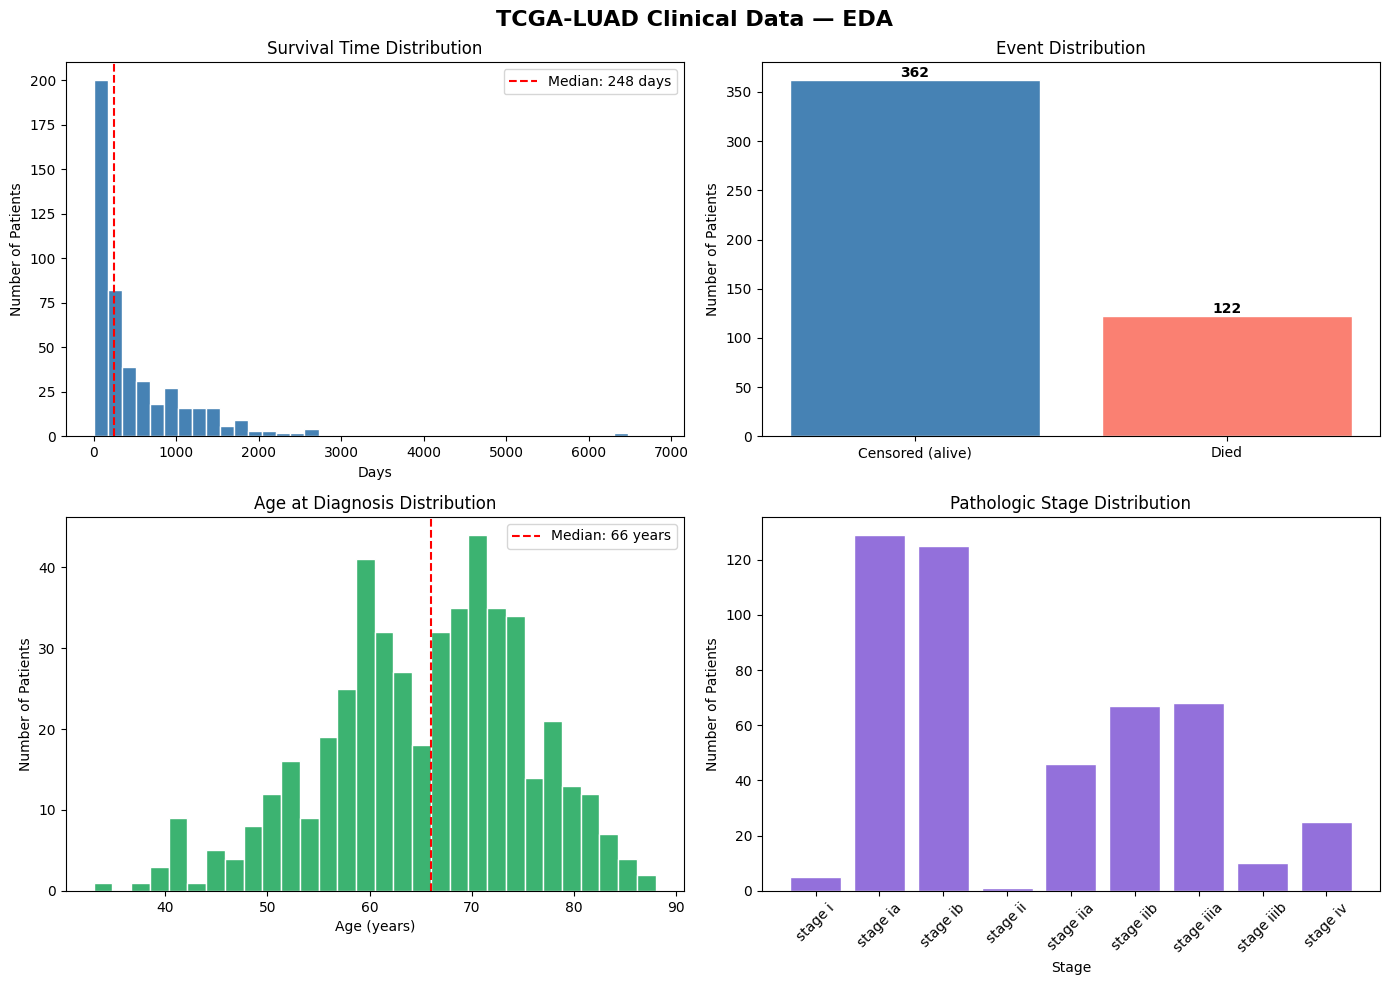

Figure saved to outputs/figures/01_clinical_eda.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TCGA-LUAD Clinical Data — EDA', fontsize=16, fontweight='bold')

# --- Plot 1: Survival time distribution ---
axes[0, 0].hist(surv['survival_time'], bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Survival Time Distribution')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Number of Patients')
axes[0, 0].axvline(surv['survival_time'].median(), color='red', 
                    linestyle='--', label=f"Median: {surv['survival_time'].median():.0f} days")
axes[0, 0].legend()

# --- Plot 2: Event distribution (dead vs alive) ---
event_counts = surv['event'].value_counts()
axes[0, 1].bar(['Censored (alive)', 'Died'], 
                [event_counts[0], event_counts[1]], 
                color=['steelblue', 'salmon'], edgecolor='white')
axes[0, 1].set_title('Event Distribution')
axes[0, 1].set_ylabel('Number of Patients')
for i, v in enumerate([event_counts[0], event_counts[1]]):
    axes[0, 1].text(i, v + 3, str(v), ha='center', fontweight='bold')

# --- Plot 3: Age distribution ---
axes[1, 0].hist(surv['age'].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Age at Diagnosis Distribution')
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].set_ylabel('Number of Patients')
axes[1, 0].axvline(surv['age'].median(), color='red', 
                    linestyle='--', label=f"Median: {surv['age'].median():.0f} years")
axes[1, 0].legend()

# --- Plot 4: Stage distribution ---
stage_counts = surv['stage'].value_counts().sort_index()
axes[1, 1].bar(stage_counts.index, stage_counts.values, 
                color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Pathologic Stage Distribution')
axes[1, 1].set_xlabel('Stage')
axes[1, 1].set_ylabel('Number of Patients')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/figures/01_clinical_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/01_clinical_eda.png")

## Step 7: Kaplan-Meier Survival Curves

Kaplan-Meier curves show the probability of survival over time.  
We plot three comparisons:
- **Overall survival** — the full cohort baseline
- **By gender** — do male and female patients differ?
- **By stage group** — early (I/II) vs late (III/IV) stage
- **By age group** — younger (<65) vs older (≥65) patients

If curves separate clearly, that variable is a meaningful predictor of survival.

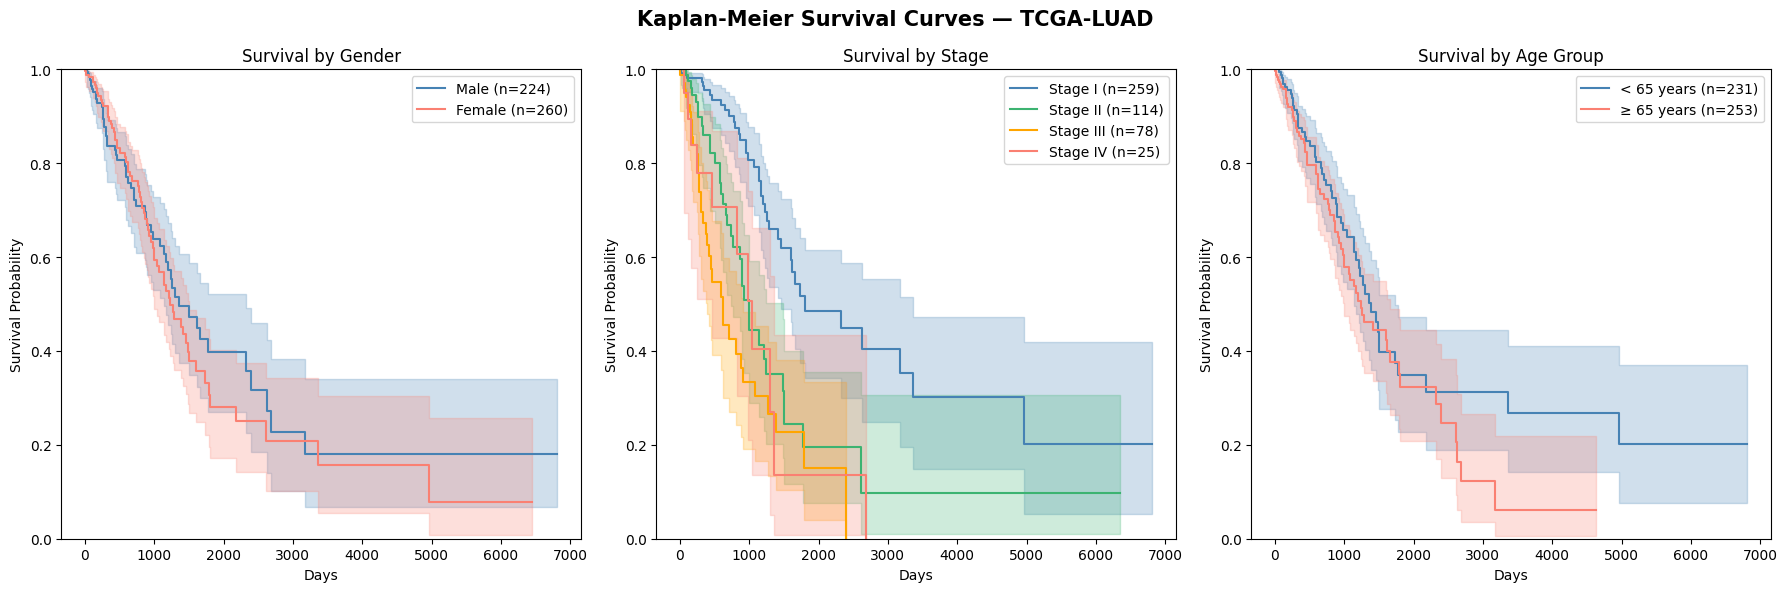

Figure saved to outputs/figures/02_kaplan_meier.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Kaplan-Meier Survival Curves — TCGA-LUAD', 
             fontsize=15, fontweight='bold')

kmf = KaplanMeierFitter()

# --- Plot 1: By Gender ---
ax = axes[0]
for group, color in [('male', 'steelblue'), ('female', 'salmon')]:
    mask = surv['gender'].str.lower() == group
    kmf.fit(
        surv.loc[mask, 'survival_time'],
        surv.loc[mask, 'event'],
        label=f"{group.capitalize()} (n={mask.sum()})"
    )
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_title('Survival by Gender')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1)
ax.legend()

# --- Plot 2: By Stage Group ---
ax = axes[1]

# Simplify stages into early (I, II) and late (III, IV)
def simplify_stage(s):
    if pd.isna(s):
        return None
    s = str(s).lower()
    if 'iv' in s:
        return 'Stage IV'
    elif 'iii' in s:
        return 'Stage III'
    elif 'ii' in s:
        return 'Stage II'
    elif 'i' in s:
        return 'Stage I'
    return None

surv['stage_group'] = surv['stage'].apply(simplify_stage)

for group, color in [('Stage I', 'steelblue'), ('Stage II', 'mediumseagreen'),
                     ('Stage III', 'orange'), ('Stage IV', 'salmon')]:
    mask = surv['stage_group'] == group
    if mask.sum() < 5:
        continue
    kmf.fit(
        surv.loc[mask, 'survival_time'],
        surv.loc[mask, 'event'],
        label=f"{group} (n={mask.sum()})"
    )
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_title('Survival by Stage')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1)
ax.legend()

# --- Plot 3: By Age Group ---
ax = axes[2]

surv['age_group'] = pd.cut(surv['age'], bins=[0, 65, 120], 
                            labels=['< 65 years', '≥ 65 years'])

for group, color in [('< 65 years', 'steelblue'), ('≥ 65 years', 'salmon')]:
    mask = surv['age_group'] == group
    kmf.fit(
        surv.loc[mask, 'survival_time'],
        surv.loc[mask, 'event'],
        label=f"{group} (n={mask.sum()})"
    )
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_title('Survival by Age Group')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('outputs/figures/02_kaplan_meier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/02_kaplan_meier.png")

## Step 8: Save Cleaned Clinical Data

We save the cleaned survival dataframe to `data/processed/` so downstream 
notebooks (RNA-seq processing, DeepSurv) can load it directly without 
repeating the cleaning steps.

In [ ]:
# Save the cleaned survival dataframe
OUTPUT_PATH = 'data/processed/clinical_survival.csv'
surv.to_csv(OUTPUT_PATH)
print(f"Saved {surv.shape[0]} patients × {surv.shape[1]} columns")
print(f"Location: {OUTPUT_PATH}")
print(f"\nColumns saved: {surv.columns.tolist()}")

Saved 484 patients × 10 columns
Location: data/processed/clinical_survival.csv

Columns saved: ['vital_status', 'days_to_death', 'days_to_last_followup', 'age', 'gender', 'stage', 'survival_time', 'event', 'stage_group', 'age_group']


# Cox Proportional Hazards Model — Intuitive Explanation

Of course. Let me explain it from scratch with a simple analogy.

---


Imagine you're trying to figure out what makes a car break down sooner. You have data on 484 cars: their age, mileage, brand, and whether they broke down or not.

You could ask:

> **"Which factors increase the risk of breaking down?"**

The Cox model answers exactly this — but for patients instead of cars, and death instead of breaking down.

---

## What does the Cox model actually do?

It looks at all your patients simultaneously and asks:

> **"Among patients who are at risk of dying at this moment — which ones actually die, and what do they have in common?"**

It does this at every point in time where a death occurs, and from all those comparisons it learns a **score for each variable** that tells you how much that variable affects the risk of dying.

---

## The Output — Hazard Ratios

The Cox model gives you one number per variable called a **Hazard Ratio (HR)**.

Think of it as a risk multiplier:

| Hazard Ratio | What it Means |
|--------------|---------------|
| HR = 2.0 | This group dies at twice the rate |
| HR = 0.5 | This group dies at half the rate |
| HR = 1.0 | No difference from baseline |

### Concrete Example

If **Stage IV** gets **HR = 3.0**, a Stage IV patient has **3× the risk of dying at any moment** compared to the reference stage, after accounting for age and gender.

If **Age** gets **HR = 1.02**, every extra year of age increases the risk by **2%**.

That sounds small, but over 20 years:

$$
1.02^{20} = 1.49
$$

So a person who is 20 years older has approximately **1.49× higher risk**.

---

## What Is It *Not* Doing?

The Cox model is **not** predicting:

> "This patient will die on day 400."

Instead, it is **ranking patients by risk**.

The patient with the highest risk score should, on average, die sooner than the patient with a lower risk score.

That ranking quality is what the **Concordance Index (C-index)** measures.

---

## Why Do We Use It as a Baseline?

There are three main reasons:

1. **Clinical gold standard**
   - Every oncology paper includes a Cox model, so reviewers expect it.

2. **Fully interpretable**
   - Every coefficient has a direct clinical or biological meaning.

3. **Benchmark for Deep Learning**
   - It is the model that our **DeepSurv** neural network must outperform.

If a complex deep learning model cannot beat this simple baseline, then there is little reason to use it.

---

## One Important Assumption

The Cox model has a key assumption called **Proportional Hazards**.

It assumes that the risk ratio between any two groups remains constant over time.

For example:

> If Stage IV patients have 3× the risk on Day 1, they still have approximately 3× the risk on Day 1000.

The survival curves may decline, but their relative separation stays roughly the same.

### Visual Intuition

If you look at a Kaplan–Meier survival plot:

- Curves that remain separated without crossing much are a good sign.
- Curves that frequently cross may indicate that the proportional hazards assumption is violated.

In our stage-based Kaplan–Meier plot, the curves separate cleanly and do not cross much, suggesting that the assumption is reasonably satisfied.

---

## Summary

The Cox Proportional Hazards Model:

- Compares patients who are still at risk at each death time.
- Learns how each variable affects the risk of death.
- Reports effects as **Hazard Ratios (HRs)**.
- Ranks patients by risk rather than predicting an exact death date.
- Serves as the standard baseline for survival analysis studies.
- Assumes that relative risks between groups stay constant over time.

### Key Idea

> The Cox model tells us **who is more likely to die sooner and by how much**, not **exactly when they will die**.

## Step 9: Cox Proportional Hazards Model — Clinical Baseline

We build a Cox model using three clinical variables:
- **Age** — continuous, in years
- **Gender** — binary (male/female)
- **Stage group** — categorical (Stage I / II / III / IV)

This is **Baseline 1** from our research proposal — the clinical standard of care benchmark.  
Every downstream model (DeepSurv, fusion) must beat this C-index to justify its complexity.

In [ ]:
from lifelines import CoxPHFitter

# --- Prepare the Cox input dataframe ---
# Cox model needs: survival_time, event, and features
# All features must be numeric — we encode categorical variables

cox_df = pd.DataFrame({
    'survival_time' : surv['survival_time'],
    'event'         : surv['event'],
    'age'           : surv['age'],
    'is_male'       : (surv['gender'].str.lower() == 'male').astype(int),
    'stage_II'      : (surv['stage_group'] == 'Stage II').astype(int),
    'stage_III'     : (surv['stage_group'] == 'Stage III').astype(int),
    'stage_IV'      : (surv['stage_group'] == 'Stage IV').astype(int),
})

# Drop rows with any missing values in these columns
cox_df = cox_df.dropna()
print(f"Patients used for Cox model: {cox_df.shape[0]}")
print(f"\nFeature matrix preview:")
cox_df.head()

Patients used for Cox model: 484

Feature matrix preview:


,survival_time,event,age,is_male,stage_II,stage_III,stage_IV
patient.bcr_patient_barcode,,,,,,,
tcga-05-4245,395.0,0,81.0,1,0,1,0
tcga-05-4249,1158.0,0,67.0,1,0,0,0
tcga-05-4250,121.0,1,79.0,0,0,1,0
tcga-05-4382,607.0,0,68.0,1,0,0,0
tcga-05-4384,426.0,0,66.0,1,0,1,0


In [ ]:
# --- Fit the Cox model ---
cph = CoxPHFitter()
cph.fit(
    cox_df,
    duration_col='survival_time',   # column containing time
    event_col='event'                # column containing 0/1 death indicator
)

# Print the model summary
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 484 total observations, 362 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 484
number of events observed = 122
   partial log-likelihood = -552.38
         time fit was run = 2026-06-03 23:04:36 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.02      1.02      0.01           -0.00            0.04                1.00                1.04
is_male   -0.25      0.78      0.19           -0.62            0.12                0.54                1.13
stage_II   0.93      2.54      0.23            0.47            1.39                1.61                4.02
stage_III  1.47      4.33      0.23            1.01            1.93                2.74                6.86
stage_IV   1.30      3.67      0.35            0.62            1.98                1.85                7.28

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  1.95   0.05      4.29
is_male      0.00 -1.32   0.19      2.43
stage_II     0.00  3.99 <0.005     13.86
stage_III    0.00  6.26 <0.005     31.32
stage_IV     0.00  3.73 <0.005     12.36
---
Concordance = 0.70
Partial AIC = 1114.76
log-likelihood ratio test = 47.46 on 5 df
-log2(p) of ll-ratio test = 27.70

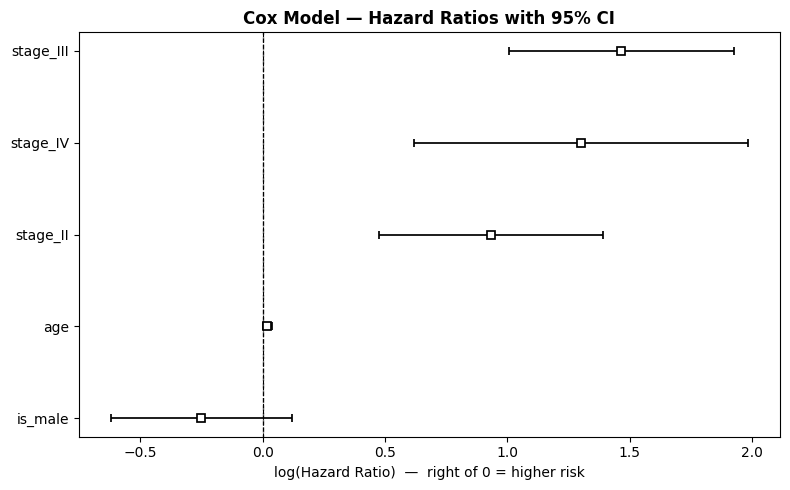

C-index (Baseline Cox Model): 0.7001

Interpretation: The model correctly ranks 70.0% of patient pairs by survival risk.


In [ ]:
# --- Plot the hazard ratios with confidence intervals ---
fig, ax = plt.subplots(figsize=(8, 5))

cph.plot(ax=ax)
ax.set_title('Cox Model — Hazard Ratios with 95% CI', fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('log(Hazard Ratio)  —  right of 0 = higher risk')

plt.tight_layout()
plt.savefig('outputs/figures/03_cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print the C-index clearly ---
c_index = cph.concordance_index_
print(f"C-index (Baseline Cox Model): {c_index:.4f}")
print(f"\nInterpretation: The model correctly ranks {c_index:.1%} of patient pairs by survival risk.")

In [ ]:
# --- Save Cox model results to CSV ---
results = cph.summary.copy()
results.to_csv('outputs/results/cox_baseline_results.csv')
print("Cox results saved to outputs/results/cox_baseline_results.csv")

# --- Final summary ---
print(f"\n{'='*50}")
print(f"BASELINE MODEL SUMMARY")
print(f"{'='*50}")
print(f"Model       : Cox Proportional Hazards")
print(f"Features    : age, gender, stage")
print(f"Patients    : 484")
print(f"Events      : 122 deaths")
print(f"C-index     : {cph.concordance_index_:.4f}")
print(f"{'='*50}")
print(f"Target to beat in Phase 4 (DeepSurv): > 0.70")

Cox results saved to outputs/results/cox_baseline_results.csv

BASELINE MODEL SUMMARY
Model       : Cox Proportional Hazards
Features    : age, gender, stage
Patients    : 484
Events      : 122 deaths
C-index     : 0.7001
Target to beat in Phase 4 (DeepSurv): > 0.70


FileNotFoundError: [Errno 2] No such file or directory: 'models/cox_clinical.pkl'